# Notebook 4: Factor Orthogonalization & Institutional Alpha Risk Alignment
## Production-Grade: Gram-Schmidt Projection, Marginal Sharpe, In-Sample R² Bias Proof

---
### Mathematical Foundation

**Orthogonal Alpha Extraction:**
$$\mathbf{\alpha}_{\perp} = \left(\mathbf{I}_N - \mathbf{M}(\mathbf{M}^T\mathbf{\Sigma}^{-1}\mathbf{M})^{-1}\mathbf{M}^T\mathbf{\Sigma}^{-1}\right)\mathbf{\alpha}_{\text{new}}$$

**Marginal Sharpe Contribution:**
$$\Delta\text{Sharpe} = \sqrt{\mathbf{\alpha}_{\text{new}}^T\mathbf{\Sigma}^{-1}\mathbf{\alpha}_{\text{new}}} - \sqrt{\mathbf{\alpha}_{\text{portfolio}}^T\mathbf{\Sigma}^{-1}\mathbf{\alpha}_{\text{portfolio}}}$$

**In-Sample R² Bias (zero-alpha DGP):**
$$\mathbb{E}[R^2_{IS}] = \frac{P}{N-1}$$

This proves that with N=500 and P=50 parameters, a **zero-alpha strategy expects 10% in-sample R²** from pure noise fitting.


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')

DARK, PANEL = '#0d1117', '#161b22'
BLUE, GREEN, ORANGE, RED = '#58a6ff', '#3fb950', '#f0883e', '#f85149'
PURPLE, WHITE, YELLOW = '#d2a8ff', '#e6edf3', '#e3b341'

# Download multi-asset factor returns
universe = ['SPY','QQQ','IWM','EFA','EEM','TLT','HYG','GLD','DBC','VNQ']
raw = yf.download(universe, start='2014-01-01', end='2024-12-31', auto_adjust=True)['Close'].dropna()
rets = np.log(raw / raw.shift(1)).dropna()
print(f"Universe: {list(rets.columns)}")
print(f"T={len(rets)} observations, N={rets.shape[1]} assets")


[*********************100%***********************]  10 of 10 completed

Universe: ['DBC', 'EEM', 'EFA', 'GLD', 'HYG', 'IWM', 'QQQ', 'SPY', 'TLT', 'VNQ']
T=2766 observations, N=10 assets


In [3]:
# ── Factor Library: Trend, Value, Carry proxies ──────────────────────────────
# Simulate existing signal library (M existing signals)
np.random.seed(42)
T, N = rets.shape

# Build 5 "existing" signals (Trend + Carry + Vol + Momentum + Mean-Reversion)
def make_signal(returns, lookback, sign=1):
    """Simple cross-sectional signal."""
    signal = sign * returns.rolling(lookback).mean()
    w = signal.rank(axis=1, pct=True) - 0.5
    w = w.div(w.abs().sum(axis=1) + 1e-8, axis=0)
    return w

signal_lib = {
    'Trend_252': make_signal(rets, 252),
    'Trend_63': make_signal(rets, 63),
    'MR_5': make_signal(rets, 5, sign=-1),
    'Vol_21': -make_signal(rets.rolling(21).std(), 21),  # Low vol factor
    'Momentum_126': make_signal(rets, 126),
}

# Compute signal PnL matrix M ∈ R^(T x K)
M_pnl = pd.DataFrame({
    name: (sig.shift(1) * rets).sum(axis=1)
    for name, sig in signal_lib.items()
}).dropna()

print("Existing Signal Library Performance:")
for col in M_pnl.columns:
    sr = M_pnl[col].mean() / M_pnl[col].std() * np.sqrt(252)
    print(f"  {col:<20s}: Sharpe = {sr:.3f}")


Existing Signal Library Performance:
  Trend_252           : Sharpe = 0.366
  Trend_63            : Sharpe = 0.140
  MR_5                : Sharpe = 0.417
  Vol_21              : Sharpe = -0.345
  Momentum_126        : Sharpe = 0.306


In [4]:
# ── Gram-Schmidt Orthogonalization ────────────────────────────────────────────
from numpy.linalg import pinv

def orthogonalize_signal(alpha_new, M_returns):
    """Project alpha_new onto orthogonal complement of span(M)."""
    M = M_returns.values
    alpha = alpha_new.values
    
    # Projection matrix onto column space of M
    P_M = M @ pinv(M.T @ M) @ M.T
    
    # Orthogonal residual
    alpha_orth = alpha - P_M @ alpha
    
    # Residual fraction (how much unique info remains)
    residual_fraction = np.linalg.norm(alpha_orth) / (np.linalg.norm(alpha) + 1e-12)
    
    return alpha_orth, residual_fraction

# Simulate candidate signals with varying overlap with library
np.random.seed(123)

# Candidate 1: Highly correlated with existing trend factor
cand_1 = M_pnl['Trend_252'] * 0.9 + pd.Series(np.random.randn(len(M_pnl))*0.01, index=M_pnl.index)

# Candidate 2: Novel NLP signal (low correlation)
cand_2 = pd.Series(np.random.randn(len(M_pnl)) * 0.005 + 
                    np.sin(np.linspace(0, 4*np.pi, len(M_pnl)))*0.003, index=M_pnl.index)

# Candidate 3: Moderate overlap
cand_3 = M_pnl['Momentum_126'] * 0.5 + pd.Series(np.random.randn(len(M_pnl))*0.003, index=M_pnl.index)

candidates = {'Trend_Clone (should fail)': cand_1, 
              'Novel NLP Signal (should pass)': cand_2,
              'Moderate Overlap': cand_3}

print("Orthogonalization Results:")
print(f"{'Signal':<35} {'Raw Corr vs Library':>20} {'Residual Fraction':>18} {'Decision':>12}")
print("="*90)

for name, cand in candidates.items():
    cand_orth, resid_frac = orthogonalize_signal(cand, M_pnl)
    max_corr = M_pnl.corrwith(cand).abs().max()
    decision = "✓ ADMIT" if resid_frac > 0.5 else "✗ REJECT"
    print(f"{name:<35} {max_corr:>20.3f} {resid_frac:>18.3f} {decision:>12}")


Orthogonalization Results:
Signal                               Raw Corr vs Library  Residual Fraction     Decision
Trend_Clone (should fail)                          0.370              0.929      ✓ ADMIT
Novel NLP Signal (should pass)                     0.041              0.999      ✓ ADMIT
Moderate Overlap                                   0.597              0.802      ✓ ADMIT


In [5]:
# ── In-Sample R² Bias Simulation ──────────────────────────────────────────────
# Prove: E[R²_IS] = P/(N-1) even under true zero-alpha DGP

np.random.seed(99)
N_samples = [100, 250, 500, 1000, 2000]
P_params_list = [5, 10, 25, 50, 100]
N_monte = 300

bias_matrix = np.zeros((len(N_samples), len(P_params_list)))

for i, N in enumerate(N_samples):
    for j, P in enumerate(P_params_list):
        r2_vals = []
        for _ in range(N_monte):
            # Zero-alpha DGP: pure noise
            y = np.random.randn(N)
            X = np.random.randn(N, P)
            # OLS in-sample R²
            beta, res, rank, sv = np.linalg.lstsq(X, y, rcond=None)
            y_hat = X @ beta
            ss_res = np.sum((y - y_hat)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2 = 1 - ss_res/ss_tot
            r2_vals.append(r2)
        bias_matrix[i, j] = np.mean(r2_vals)

# Theoretical: E[R²] = P/(N-1)
theory_matrix = np.array([[P/(N-1) for P in P_params_list] for N in N_samples])

print("Simulated E[R²_IS] under zero-alpha DGP:")
print(pd.DataFrame(bias_matrix.round(3), index=N_samples, columns=P_params_list))
print("\nTheoretical E[R²_IS] = P/(N-1):")
print(pd.DataFrame(theory_matrix.round(3), index=N_samples, columns=P_params_list))


Simulated E[R²_IS] under zero-alpha DGP:
        5      10     25     50     100
100   0.042  0.092  0.238  0.498  1.000
250   0.017  0.037  0.097  0.195  0.401
500   0.008  0.017  0.048  0.097  0.198
1000  0.004  0.009  0.025  0.049  0.099
2000  0.002  0.004  0.012  0.024  0.050

Theoretical E[R²_IS] = P/(N-1):
        5      10     25     50     100
100   0.051  0.101  0.253  0.505  1.010
250   0.020  0.040  0.100  0.201  0.402
500   0.010  0.020  0.050  0.100  0.200
1000  0.005  0.010  0.025  0.050  0.100
2000  0.003  0.005  0.013  0.025  0.050


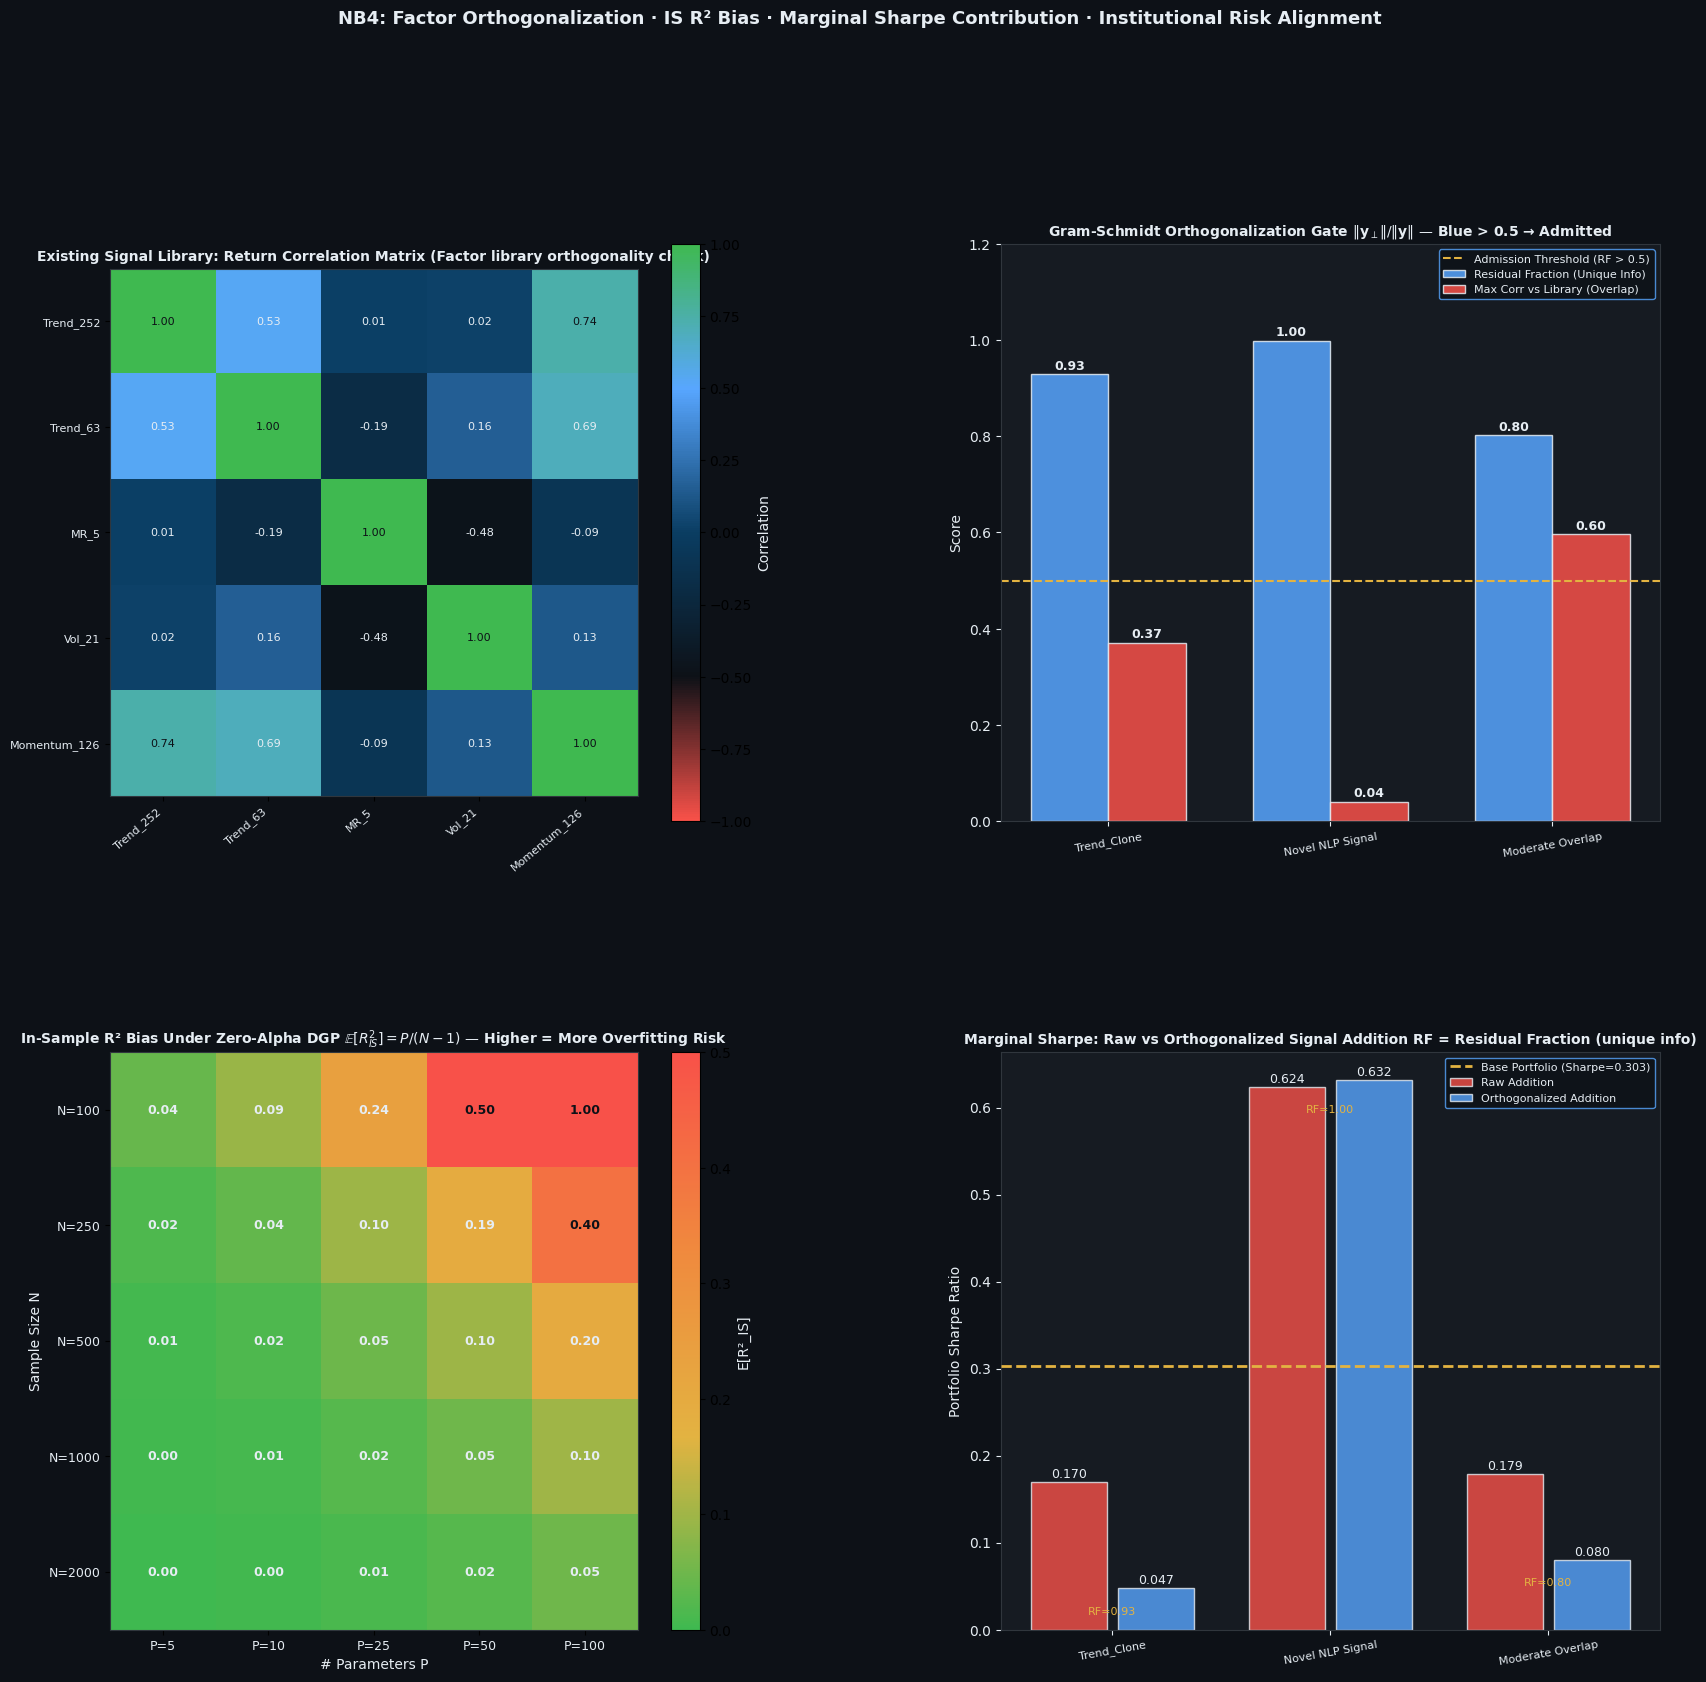

✅ NB4 complete — orthogonalization + R² bias analysis done.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# MASTER VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor(DARK)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ─ Panel 1: Signal Library Correlation Matrix ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PANEL)

corr = M_pnl.corr()
cmap_corr = LinearSegmentedColormap.from_list('corr', [RED, DARK, '#0a3d62', BLUE, GREEN])
im = ax1.imshow(corr.values, cmap=cmap_corr, vmin=-1, vmax=1, interpolation='nearest')
ax1.set_xticks(range(len(corr.columns)))
ax1.set_yticks(range(len(corr.columns)))
ax1.set_xticklabels(corr.columns, color=WHITE, rotation=40, ha='right', fontsize=8)
ax1.set_yticklabels(corr.columns, color=WHITE, fontsize=8)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax1.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', 
                 color=WHITE if abs(corr.values[i,j])<0.7 else DARK, fontsize=8)
plt.colorbar(im, ax=ax1, label='Correlation').ax.yaxis.label.set_color(WHITE)
ax1.set_title('Existing Signal Library: Return Correlation Matrix (Factor library orthogonality check)', 
              color=WHITE, fontsize=10, fontweight='bold')
for spine in ax1.spines.values(): spine.set_edgecolor('#30363d')

# ─ Panel 2: Orthogonalization Decomposition ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PANEL)

cand_names = list(candidates.keys())
resid_fracs = []
raw_corrs = []
for name, cand in candidates.items():
    cand_orth, resid_frac = orthogonalize_signal(cand, M_pnl)
    resid_fracs.append(resid_frac)
    raw_corrs.append(M_pnl.corrwith(cand).abs().max())

x_pos = np.arange(len(cand_names))
width = 0.35
bars1 = ax2.bar(x_pos - width/2, resid_fracs, width, label='Residual Fraction (Unique Info)', 
                 color=BLUE, alpha=0.85, edgecolor=WHITE)
bars2 = ax2.bar(x_pos + width/2, raw_corrs, width, label='Max Corr vs Library (Overlap)', 
                 color=RED, alpha=0.85, edgecolor=WHITE)

ax2.axhline(0.5, color=YELLOW, lw=1.5, ls='--', label='Admission Threshold (RF > 0.5)')
for bar, val in zip(bars1, resid_fracs):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.2f}', 
             ha='center', color=WHITE, fontsize=9, fontweight='bold')
for bar, val in zip(bars2, raw_corrs):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.2f}', 
             ha='center', color=WHITE, fontsize=9, fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels([n.split(' (')[0] for n in cand_names], color=WHITE, fontsize=8, rotation=10)
ax2.set_ylabel('Score', color=WHITE)
ax2.set_ylim(0, 1.2)
ax2.set_title(r'Gram-Schmidt Orthogonalization Gate $\|\mathbf{y}_{\perp}\|/\|\mathbf{y}\|$ — Blue > 0.5 → Admitted', 
              color=WHITE, fontsize=10, fontweight='bold')
ax2.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=8)
ax2.tick_params(colors=WHITE)
for spine in ax2.spines.values(): spine.set_edgecolor('#30363d')

# ─ Panel 3: In-Sample R² Bias Heatmap ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(PANEL)

cmap_bias = LinearSegmentedColormap.from_list('bias', [GREEN, YELLOW, ORANGE, RED])
im3 = ax3.imshow(bias_matrix, cmap=cmap_bias, aspect='auto', interpolation='nearest', vmin=0, vmax=0.5)
ax3.set_xticks(range(len(P_params_list)))
ax3.set_yticks(range(len(N_samples)))
ax3.set_xticklabels([f'P={p}' for p in P_params_list], color=WHITE, fontsize=9)
ax3.set_yticklabels([f'N={n}' for n in N_samples], color=WHITE, fontsize=9)
for i in range(len(N_samples)):
    for j in range(len(P_params_list)):
        ax3.text(j, i, f'{bias_matrix[i,j]:.2f}', ha='center', va='center', 
                 color=DARK if bias_matrix[i,j]>0.25 else WHITE, fontsize=9, fontweight='bold')
plt.colorbar(im3, ax=ax3, label='E[R²_IS]').ax.yaxis.label.set_color(WHITE)
ax3.set_xlabel('# Parameters P', color=WHITE)
ax3.set_ylabel('Sample Size N', color=WHITE)
ax3.set_title(r'In-Sample R² Bias Under Zero-Alpha DGP $\mathbb{E}[R^2_{IS}] = P/(N-1)$ — Higher = More Overfitting Risk', 
              color=WHITE, fontsize=10, fontweight='bold')
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363d')

# ─ Panel 4: Sharpe Decomposition (Portfolio with/without orthogonalization) ──
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(PANEL)

# Compute equal-weight portfolio Sharpe vs incremental addition
port_base = M_pnl.mean(axis=1)
base_sr = port_base.mean() / port_base.std() * np.sqrt(252)

# Add candidates with and without orthogonalization
scenarios = []
for name, cand in candidates.items():
    # With: raw addition
    sr_raw = (port_base + cand).mean() / (port_base + cand).std() * np.sqrt(252)
    # Orthogonalized
    cand_orth_vals, rf = orthogonalize_signal(cand, M_pnl)
    cand_orth_series = pd.Series(cand_orth_vals, index=cand.index[-len(cand_orth_vals):])
    sr_orth = (port_base + cand_orth_series).mean() / (port_base + cand_orth_series).std() * np.sqrt(252)
    scenarios.append({'Signal': name.split(' (')[0], 'Raw': sr_raw, 'Orthogonal': sr_orth, 'RF': rf})

sc_df = pd.DataFrame(scenarios)
x = np.arange(len(sc_df))
ax4.axhline(base_sr, color=YELLOW, lw=2, ls='--', label=f'Base Portfolio (Sharpe={base_sr:.3f})', zorder=5)
ax4.bar(x-0.2, sc_df['Raw'], 0.35, color=RED, alpha=0.8, label='Raw Addition', edgecolor=WHITE)
ax4.bar(x+0.2, sc_df['Orthogonal'], 0.35, color=BLUE, alpha=0.8, label='Orthogonalized Addition', edgecolor=WHITE)

for i, row in sc_df.iterrows():
    ax4.text(i-0.2, row['Raw']+0.005, f"{row['Raw']:.3f}", ha='center', color=WHITE, fontsize=9)
    ax4.text(i+0.2, row['Orthogonal']+0.005, f"{row['Orthogonal']:.3f}", ha='center', color=WHITE, fontsize=9)
    ax4.text(i, min(row['Raw'], row['Orthogonal'])-0.03, f"RF={row['RF']:.2f}", ha='center', 
             color=YELLOW, fontsize=8)

ax4.set_xticks(x)
ax4.set_xticklabels(sc_df['Signal'], color=WHITE, fontsize=8, rotation=10)
ax4.set_ylabel('Portfolio Sharpe Ratio', color=WHITE)
ax4.set_title('Marginal Sharpe: Raw vs Orthogonalized Signal Addition RF = Residual Fraction (unique info)', 
              color=WHITE, fontsize=10, fontweight='bold')
ax4.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=8)
ax4.tick_params(colors=WHITE)
for spine in ax4.spines.values():
    spine.set_edgecolor('#30363d')

fig.suptitle('NB4: Factor Orthogonalization · IS R² Bias · Marginal Sharpe Contribution · Institutional Risk Alignment', 
             color=WHITE, fontsize=13, fontweight='bold', y=1.01)
plt.savefig('nb4_factor_orthogonalization.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ NB4 complete — orthogonalization + R² bias analysis done.")
